In [1]:
# Deep Learning Framework
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Data Processing
import numpy as np
import pandas as pd
from PIL import Image
import cv2

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics and Evaluation
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    auc,
    f1_score, 
    recall_score, 
    precision_score
)
from sklearn.preprocessing import label_binarize

# Utilities
import os
import json
import time
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
print("="*80)
print("ENVIRONMENT VERIFICATION")
print("="*80)

# Check PyTorch version
print(f"\n✓ PyTorch Version: {torch.__version__}")

# Check GPU availability
if torch.cuda.is_available():
    print(f"✅ CUDA Available: {torch.cuda.is_available()}")
    print(f"✅ Number of GPUs: {torch.cuda.device_count()}")
    
    for i in range(torch.cuda.device_count()):
        gpu_name = torch.cuda.get_device_name(i)
        gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"\n   GPU {i}: {gpu_name}")
        print(f"   Memory: {gpu_memory:.2f} GB")
    
    device = torch.device('cuda:0')
    print(f"\n🎮 Using device: {device}")
    print(f"   Selected: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  CUDA not available. Using CPU.")
    print("   Training will be slower but still work.")
    device = torch.device('cpu')

print("\n" + "="*80)
print("Environment ready! ✅")
print("="*80)

ENVIRONMENT VERIFICATION

✓ PyTorch Version: 2.1.2+cu118
✅ CUDA Available: True
✅ Number of GPUs: 2

   GPU 0: NVIDIA RTX A6000
   Memory: 51.53 GB

   GPU 1: NVIDIA RTX A6000
   Memory: 51.53 GB

🎮 Using device: cuda:0
   Selected: NVIDIA RTX A6000

Environment ready! ✅


In [3]:
# Auto-detect paths (works from any location)
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    BASE_DIR = NOTEBOOK_DIR.parent
else:
    BASE_DIR = NOTEBOOK_DIR

# Configuration Dictionary
CONFIG = {
    # ========== PATHS ==========
     'DATA_DIR': r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\data\Alzheimer_MRI_4_classes_dataset',
     'OUTPUT_DIR': r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch',
    
    # ========== MODEL HYPERPARAMETERS ==========
    # Image settings
    'IMG_SIZE': 224,  # Standard for CNN (224x224)
    
    # Training settings
    'BATCH_SIZE': 128,  # Optimized for RTX A6000 (49GB VRAM)
    'LEARNING_RATE': 0.001,  # Standard Adam learning rate
    'MAX_EPOCHS': 100,  # Maximum epochs (early stopping will cut this)
    
    # Classes
    'NUM_CLASSES': 4,
    'CLASS_NAMES': ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented'],
    
    # ========== DATA SPLIT ==========
    'TRAIN_SPLIT': 0.8,  # 80% for training
    'VAL_SPLIT': 0.1,    # 10% for validation
    'TEST_SPLIT': 0.1,   # 10% for testing
    
    # ========== EARLY STOPPING ==========
    'EARLY_STOP_PATIENCE': 7,  # Stop if no improvement for 7 epochs
    'EARLY_STOP_MIN_DELTA': 0.001,  # Minimum improvement threshold (0.1%)
    
    # ========== LEARNING RATE SCHEDULER ==========
    'LR_PATIENCE': 3,  # Reduce LR if no improvement for 3 epochs
    'LR_FACTOR': 0.5,  # Reduce LR by 50%
    
    # ========== MISC ==========
    'RANDOM_SEED': 42,
    'NUM_WORKERS': 0,  # Set to 0 for Windows compatibility
}

# Set random seeds for reproducibility
torch.manual_seed(CONFIG['RANDOM_SEED'])
np.random.seed(CONFIG['RANDOM_SEED'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(CONFIG['RANDOM_SEED'])

# Create output directory
os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

# Verify data directory exists
if not os.path.exists(CONFIG['DATA_DIR']):
    print("\n❌ ERROR: Data directory not found!")
    print(f"   Looking for: {CONFIG['DATA_DIR']}")
    print(f"\n🔧 FIX: Update CONFIG['DATA_DIR'] to correct path")
    print(f"   Current directory: {Path.cwd()}")
else:
    print("\n✅ Configuration loaded successfully!")
    print(f"\n📁 Paths:")
    print(f"   Data: {CONFIG['DATA_DIR']}")
    print(f"   Output: {CONFIG['OUTPUT_DIR']}")
    
    print(f"\n📊 Training Settings:")
    print(f"   Batch size: {CONFIG['BATCH_SIZE']}")
    print(f"   Learning rate: {CONFIG['LEARNING_RATE']}")
    print(f"   Max epochs: {CONFIG['MAX_EPOCHS']} (with early stopping)")
    print(f"   Image size: {CONFIG['IMG_SIZE']}x{CONFIG['IMG_SIZE']}")
    
    print(f"\n🛑 Early Stopping:")
    print(f"   Patience: {CONFIG['EARLY_STOP_PATIENCE']} epochs")
    print(f"   Min improvement: {CONFIG['EARLY_STOP_MIN_DELTA']*100:.1f}%")
    
    # Show dataset classes
    print(f"\n📂 Checking dataset...")
    total_images = 0
    for class_name in CONFIG['CLASS_NAMES']:
        class_path = os.path.join(CONFIG['DATA_DIR'], class_name)
        if os.path.exists(class_path):
            n_images = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
            total_images += n_images
            print(f"   ✓ {class_name}: {n_images} images")
        else:
            print(f"   ✗ {class_name}: NOT FOUND")
    
    print(f"\n   Total images: {total_images:,}")
    print(f"   Train: ~{int(total_images * CONFIG['TRAIN_SPLIT']):,} images")
    print(f"   Val: ~{int(total_images * CONFIG['VAL_SPLIT']):,} images")
    print(f"   Test: ~{int(total_images * CONFIG['TEST_SPLIT']):,} images")


✅ Configuration loaded successfully!

📁 Paths:
   Data: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\data\Alzheimer_MRI_4_classes_dataset
   Output: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch

📊 Training Settings:
   Batch size: 128
   Learning rate: 0.001
   Max epochs: 100 (with early stopping)
   Image size: 224x224

🛑 Early Stopping:
   Patience: 7 epochs
   Min improvement: 0.1%

📂 Checking dataset...
   ✓ MildDemented: 896 images
   ✓ ModerateDemented: 64 images
   ✓ NonDemented: 3200 images
   ✓ VeryMildDemented: 2240 images

   Total images: 6,400
   Train: ~5,120 images
   Val: ~640 images
   Test: ~640 images


In [4]:
class EarlyStopping:
    """
    Early Stopping - Stops training when validation loss stops improving
    
    Why we need this:
    - Prevents overfitting (model memorizing training data)
    - Saves time (stops when further training is useless)
    - Finds optimal number of epochs automatically
    
    Parameters:
    - patience: How many epochs to wait before stopping
    - min_delta: Minimum improvement to count as progress
    """
    
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_epoch = 0
        
    def __call__(self, val_loss, epoch):
        """
        Check if we should stop training
        
        Logic:
        1. If first epoch, just save the loss
        2. If loss improved significantly, reset counter
        3. If loss didn't improve, increment counter
        4. If counter reaches patience, stop training
        """
        if self.best_loss is None:
            # First epoch - just record the loss
            self.best_loss = val_loss
            self.best_epoch = epoch
        elif val_loss > self.best_loss - self.min_delta:
            # No significant improvement
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            # Significant improvement!
            self.best_loss = val_loss
            self.best_epoch = epoch
            self.counter = 0
        
        return self.early_stop


class MetricTracker:
    """
    Tracks all metrics during training
    
    Why we need this:
    - Records training history for analysis
    - Makes it easy to plot learning curves
    - Saves data for later review
    """
    
    def __init__(self):
        self.history = {
            'epoch': [],
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_f1': [],
            'val_precision': [],
            'val_recall': [],
            'learning_rate': [],
            'epoch_time': []
        }
    
    def update(self, epoch, metrics):
        """Add metrics for current epoch"""
        self.history['epoch'].append(epoch)
        for key, value in metrics.items():
            if key in self.history:
                self.history[key].append(value)
    
    def get_best(self, metric='val_acc', mode='max'):
        """Get best value of a metric"""
        if mode == 'max':
            return max(self.history[metric])
        else:
            return min(self.history[metric])
    
    def save_csv(self, filepath):
        """Save history to CSV file"""
        df = pd.DataFrame(self.history)
        df.to_csv(filepath, index=False)


def format_time(seconds):
    """
    Convert seconds to readable format
    
    Example:
    - 90 seconds → "1m 30s"
    - 3665 seconds → "1h 1m 5s"
    """
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    
    if hours > 0:
        return f"{hours}h {minutes}m {secs}s"
    elif minutes > 0:
        return f"{minutes}m {secs}s"
    else:
        return f"{secs}s"


def print_training_summary(epoch, total_epochs, metrics, epoch_time):
    """
    Print a nice summary of training progress
    
    Makes the output readable and professional
    """
    print(f"\n{'='*80}")
    print(f"Epoch {epoch}/{total_epochs} - {format_time(epoch_time)}")
    print(f"{'='*80}")
    print(f"Train Loss: {metrics['train_loss']:.4f} | Train Acc: {metrics['train_acc']:.2f}%")
    print(f"Val Loss:   {metrics['val_loss']:.4f} | Val Acc:   {metrics['val_acc']:.2f}%")
    print(f"Val F1:     {metrics['val_f1']:.4f} | Precision:  {metrics['val_precision']:.4f} | Recall: {metrics['val_recall']:.4f}")
    print(f"Learning Rate: {metrics['learning_rate']:.6f}")


print("✅ Helper functions defined successfully!")
print("\nAvailable utilities:")
print("  • EarlyStopping - Automatic training termination")
print("  • MetricTracker - Records all training metrics")
print("  • format_time - Human-readable time formatting")
print("  • print_training_summary - Clean progress display")

✅ Helper functions defined successfully!

Available utilities:
  • EarlyStopping - Automatic training termination
  • MetricTracker - Records all training metrics
  • format_time - Human-readable time formatting
  • print_training_summary - Clean progress display


In [5]:
class AlzheimerDataset(Dataset):
    """
    Custom Dataset for Alzheimer MRI images
    
    What this does:
    - Loads images from disk on-demand (memory efficient)
    - Applies transformations (resize, augment, normalize)
    - Returns image-label pairs for training
    
    Parameters:
    - image_paths: List of file paths to images
    - labels: List of class labels (0, 1, 2, or 3)
    - transform: Image transformations to apply
    """
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        """Return total number of samples"""
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        """
        Load and return a single sample
        
        Steps:
        1. Load image from disk
        2. Convert to RGB (some images are grayscale)
        3. Apply transformations
        4. Return (image, label) pair
        """
        # Load image
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
        
        # Get label (convert to tensor with correct type)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return image, label


# Define image transformations
print("Defining data transformations...")

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'])),
    
    # Data augmentation (creates variations to improve generalization)
    transforms.RandomHorizontalFlip(p=0.5),  # 50% chance to flip
    transforms.RandomRotation(degrees=10),    # Rotate up to 10 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Vary brightness/contrast
    
    # Convert to tensor and normalize
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                        std=[0.229, 0.224, 0.225])     # ImageNet std
])

# Validation/Test transforms (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

print("✅ Transformations defined")

# Load all image paths and labels
print("\nLoading dataset...")
all_images = []
all_labels = []

for class_idx, class_name in enumerate(CONFIG['CLASS_NAMES']):
    class_dir = os.path.join(CONFIG['DATA_DIR'], class_name)
    if os.path.exists(class_dir):
        image_files = [f for f in os.listdir(class_dir) 
                      if f.endswith(('.jpg', '.jpeg', '.png'))]
        
        for img_file in image_files:
            all_images.append(os.path.join(class_dir, img_file))
            all_labels.append(class_idx)
        
        print(f"  ✓ {class_name} (class {class_idx}): {len(image_files)} images")

# Convert to numpy arrays
all_images = np.array(all_images)
all_labels = np.array(all_labels, dtype=np.int64)  # Ensure correct type

print(f"\n✅ Loaded {len(all_images):,} total images")

# Shuffle data (important for random split)
print("\nShuffling data...")
np.random.seed(CONFIG['RANDOM_SEED'])
indices = np.random.permutation(len(all_images))
all_images = all_images[indices]
all_labels = all_labels[indices]

# Split into train/val/test
print("\nSplitting dataset...")
n_samples = len(all_images)
train_end = int(CONFIG['TRAIN_SPLIT'] * n_samples)
val_end = train_end + int(CONFIG['VAL_SPLIT'] * n_samples)

train_images = all_images[:train_end]
train_labels = all_labels[:train_end]

val_images = all_images[train_end:val_end]
val_labels = all_labels[train_end:val_end]

test_images = all_images[val_end:]
test_labels = all_labels[val_end:]

print(f"\n📊 Dataset Split:")
print(f"  Training:   {len(train_images):,} images ({len(train_images)/n_samples*100:.1f}%)")
print(f"  Validation: {len(val_images):,} images ({len(val_images)/n_samples*100:.1f}%)")
print(f"  Test:       {len(test_images):,} images ({len(test_images)/n_samples*100:.1f}%)")

# Create Dataset objects
print("\nCreating PyTorch datasets...")
train_dataset = AlzheimerDataset(train_images, train_labels, transform=train_transform)
val_dataset = AlzheimerDataset(val_images, val_labels, transform=test_transform)
test_dataset = AlzheimerDataset(test_images, test_labels, transform=test_transform)

# Create DataLoaders (handles batching and shuffling)
print("Creating data loaders...")
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=True,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\n✅ Data loaders created!")
print(f"\n📦 Batches per epoch:")
print(f"  Training:   {len(train_loader)} batches")
print(f"  Validation: {len(val_loader)} batches")
print(f"  Test:       {len(test_loader)} batches")
print(f"\n⏱️  Estimated time per epoch: ~{len(train_loader) * 1.2:.0f}s (on GPU)")

Defining data transformations...
✅ Transformations defined

Loading dataset...
  ✓ MildDemented (class 0): 896 images
  ✓ ModerateDemented (class 1): 64 images
  ✓ NonDemented (class 2): 3200 images
  ✓ VeryMildDemented (class 3): 2240 images

✅ Loaded 6,400 total images

Shuffling data...

Splitting dataset...

📊 Dataset Split:
  Training:   5,120 images (80.0%)
  Validation: 640 images (10.0%)
  Test:       640 images (10.0%)

Creating PyTorch datasets...
Creating data loaders...

✅ Data loaders created!

📦 Batches per epoch:
  Training:   40 batches
  Validation: 5 batches
  Test:       5 batches

⏱️  Estimated time per epoch: ~48s (on GPU)


Visualizing sample images...

✅ Sample visualization saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch\sample_images.png


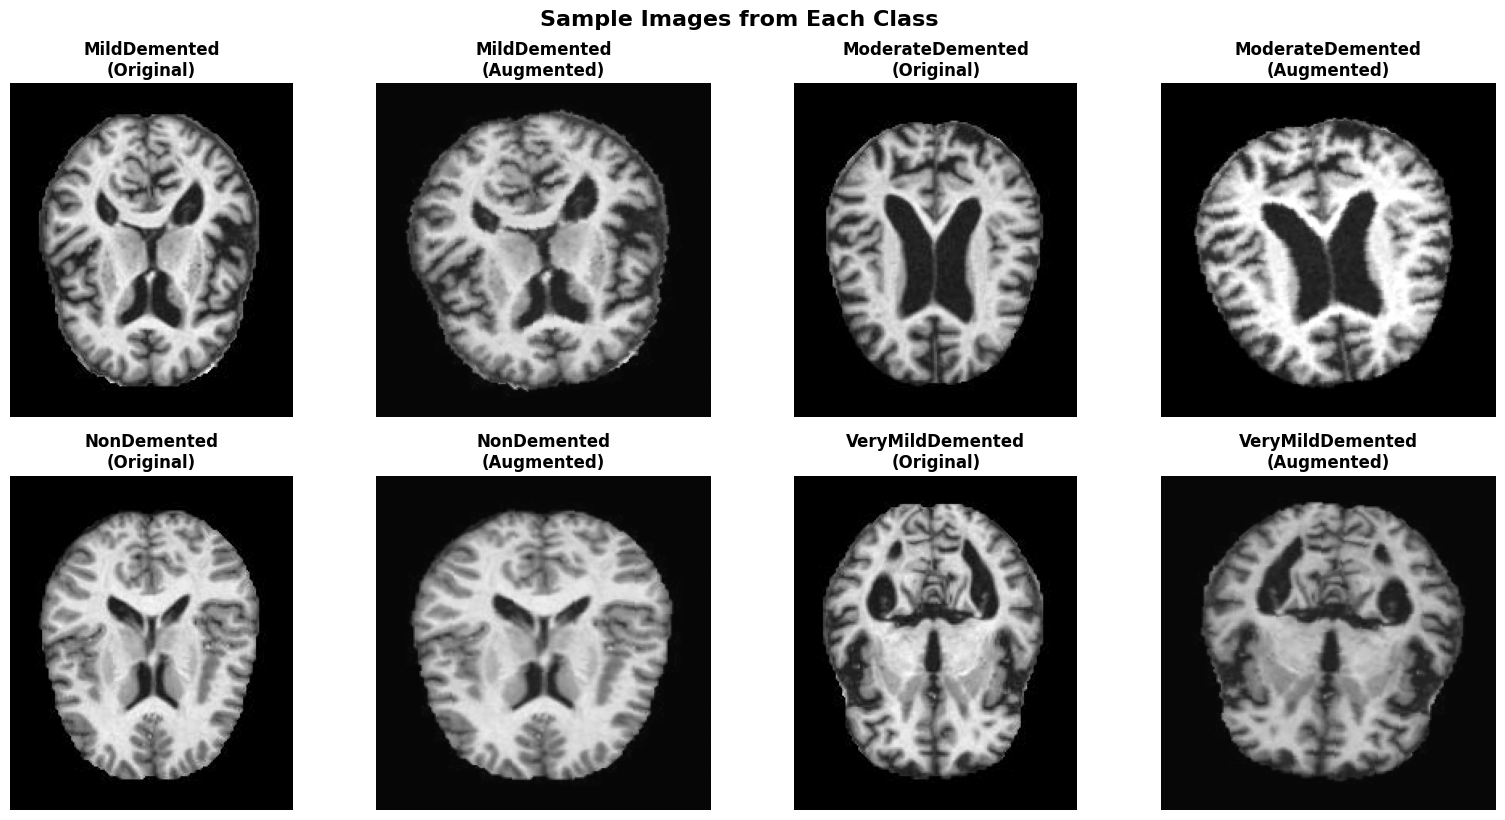


📊 Class Distribution:

Training set:
  MildDemented        :  736 images (14.37%)
  ModerateDemented    :   48 images ( 0.94%)
  NonDemented         : 2557 images (49.94%)
  VeryMildDemented    : 1779 images (34.75%)

Validation set:
  MildDemented        :   77 images (12.03%)
  ModerateDemented    :   13 images ( 2.03%)
  NonDemented         :  322 images (50.31%)
  VeryMildDemented    :  228 images (35.62%)


In [6]:
# Visualize sample images from each class
print("Visualizing sample images...\n")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

# Get one image from each class
samples_shown = 0
for class_idx in range(CONFIG['NUM_CLASSES']):
    # Find first image of this class
    idx = np.where(train_labels == class_idx)[0][0]
    
    # Load original image (before transforms)
    img_path = train_images[idx]
    image = Image.open(img_path).convert('RGB')
    
    # Show original
    axes[samples_shown].imshow(image)
    axes[samples_shown].set_title(f"{CONFIG['CLASS_NAMES'][class_idx]}\n(Original)", 
                                   fontsize=12, fontweight='bold')
    axes[samples_shown].axis('off')
    samples_shown += 1
    
    # Show augmented version
    augmented = train_transform(image)
    # Denormalize for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    augmented = augmented * std + mean
    augmented = torch.clamp(augmented, 0, 1)
    
    axes[samples_shown].imshow(augmented.permute(1, 2, 0))
    axes[samples_shown].set_title(f"{CONFIG['CLASS_NAMES'][class_idx]}\n(Augmented)",
                                   fontsize=12, fontweight='bold')
    axes[samples_shown].axis('off')
    samples_shown += 1

plt.tight_layout()
plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.02)

# Save visualization
viz_path = os.path.join(CONFIG['OUTPUT_DIR'], 'sample_images.png')
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
print(f"✅ Sample visualization saved to: {viz_path}")
plt.show()

# Print class distribution
print("\n📊 Class Distribution:")
print(f"\nTraining set:")
for class_idx, class_name in enumerate(CONFIG['CLASS_NAMES']):
    count = np.sum(train_labels == class_idx)
    percentage = count / len(train_labels) * 100
    print(f"  {class_name:20s}: {count:4d} images ({percentage:5.2f}%)")

print(f"\nValidation set:")
for class_idx, class_name in enumerate(CONFIG['CLASS_NAMES']):
    count = np.sum(val_labels == class_idx)
    percentage = count / len(val_labels) * 100
    print(f"  {class_name:20s}: {count:4d} images ({percentage:5.2f}%)")

In [7]:
class AlzheimerCNN(nn.Module):
    """
    CNN Architecture for Alzheimer's MRI Classification
    
    Architecture Overview:
    ┌─────────────────────────────────────────────────────┐
    │ Input: 224x224x3 RGB Image                         │
    ├─────────────────────────────────────────────────────┤
    │ Conv Block 1: 32 filters  → 112x112x32             │
    │ Conv Block 2: 64 filters  → 56x56x64               │
    │ Conv Block 3: 128 filters → 28x28x128              │
    │ Conv Block 4: 256 filters → 14x14x256              │
    ├─────────────────────────────────────────────────────┤
    │ Flatten → 50,176 features                          │
    │ FC Layer 1: 512 neurons                            │
    │ FC Layer 2: 256 neurons                            │
    │ Output Layer: 4 classes                            │
    └─────────────────────────────────────────────────────┘
    
    Each Conv Block:
    - 2x Conv2D layers (feature extraction)
    - BatchNorm (stabilize training)
    - ReLU activation (non-linearity)
    - MaxPool (reduce spatial dimensions)
    - Dropout (prevent overfitting)
    """
    
    def __init__(self, num_classes=4):
        super(AlzheimerCNN, self).__init__()
        
        # ========== Convolutional Block 1 ==========
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Input: 3 channels (RGB)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224→112
            nn.Dropout(p=0.25)
        )
        
        # ========== Convolutional Block 2 ==========
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112→56
            nn.Dropout(p=0.25)
        )
        
        # ========== Convolutional Block 3 ==========
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56→28
            nn.Dropout(p=0.25)
        )
        
        # ========== Convolutional Block 4 ==========
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28→14
            nn.Dropout(p=0.25)
        )
        
        # ========== Fully Connected Layers ==========
        self.fc = nn.Sequential(
            nn.Flatten(),
            
            # First FC layer
            nn.Linear(256 * 14 * 14, 512),  # 50176 → 512
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            
            # Second FC layer
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            
            # Output layer
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        """
        Forward pass through the network
        
        Flow:
        x → conv1 → conv2 → conv3 → conv4 → flatten → fc → output
        """
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.fc(x)
        return x


# Create model and move to GPU
print("Creating model...")
model = AlzheimerCNN(num_classes=CONFIG['NUM_CLASSES']).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "="*80)
print("MODEL ARCHITECTURE")
print("="*80)
print(model)

print("\n" + "="*80)
print("MODEL STATISTICS")
print("="*80)
print(f"Total parameters:      {total_params:,}")
print(f"Trainable parameters:  {trainable_params:,}")
print(f"Model size:            ~{total_params * 4 / 1024 / 1024:.2f} MB")
print(f"Device:                {device}")

# Calculate memory usage
if torch.cuda.is_available():
    # Test forward pass to measure memory
    dummy_input = torch.randn(CONFIG['BATCH_SIZE'], 3, CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']).to(device)
    with torch.no_grad():
        _ = model(dummy_input)
    
    memory_allocated = torch.cuda.memory_allocated(device) / 1e9
    memory_reserved = torch.cuda.memory_reserved(device) / 1e9
    
    print(f"\nGPU Memory Usage:")
    print(f"  Allocated: {memory_allocated:.2f} GB")
    print(f"  Reserved:  {memory_reserved:.2f} GB")
    print(f"  Available: {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")
    
    del dummy_input
    torch.cuda.empty_cache()

print("\n✅ Model created successfully!")

Creating model...

MODEL ARCHITECTURE
AlzheimerCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6)

In [8]:
print("Setting up training components...\n")

# ========== Loss Function ==========
# CrossEntropyLoss combines softmax + negative log likelihood
# Perfect for multi-class classification
criterion = nn.CrossEntropyLoss()
print(f"✓ Loss function: CrossEntropyLoss")

# ========== Optimizer ==========
# Adam: Adaptive learning rates + momentum
# Best all-around optimizer for CNNs
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['LEARNING_RATE'],
    betas=(0.9, 0.999),  # Momentum parameters
    eps=1e-8,
    weight_decay=1e-5    # L2 regularization
)
print(f"✓ Optimizer: Adam (lr={CONFIG['LEARNING_RATE']})")

# ========== Learning Rate Scheduler ==========
# Reduces LR when validation loss plateaus
# Helps fine-tune as training progresses
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',  # Minimize validation loss
    factor=CONFIG['LR_FACTOR'],  # Multiply LR by this
    patience=CONFIG['LR_PATIENCE'],  # Wait this many epochs
    verbose=True,
    min_lr=1e-7  # Don't go below this
)
print(f"✓ Scheduler: ReduceLROnPlateau (patience={CONFIG['LR_PATIENCE']}, factor={CONFIG['LR_FACTOR']})")

# ========== Early Stopping ==========
early_stopping = EarlyStopping(
    patience=CONFIG['EARLY_STOP_PATIENCE'],
    min_delta=CONFIG['EARLY_STOP_MIN_DELTA']
)
print(f"✓ Early stopping: patience={CONFIG['EARLY_STOP_PATIENCE']}, min_delta={CONFIG['EARLY_STOP_MIN_DELTA']}")

# ========== Metric Tracker ==========
metric_tracker = MetricTracker()
print(f"✓ Metric tracker: initialized")

# ========== Best Model Tracking ==========
best_val_acc = 0.0
best_model_path = os.path.join(CONFIG['OUTPUT_DIR'], 'best_model.pth')
print(f"✓ Best model will be saved to: {best_model_path}")

print("\n" + "="*80)
print("TRAINING CONFIGURATION SUMMARY")
print("="*80)
print(f"\n📊 Optimization:")
print(f"  Loss function:     CrossEntropyLoss")
print(f"  Optimizer:         Adam")
print(f"  Learning rate:     {CONFIG['LEARNING_RATE']}")
print(f"  Weight decay:      1e-5 (L2 regularization)")

print(f"\n⚙️  Learning Rate Schedule:")
print(f"  Strategy:          ReduceLROnPlateau")
print(f"  Patience:          {CONFIG['LR_PATIENCE']} epochs")
print(f"  Reduction factor:  {CONFIG['LR_FACTOR']}x")
print(f"  Minimum LR:        1e-7")

print(f"\n🛑 Early Stopping:")
print(f"  Enabled:           Yes")
print(f"  Patience:          {CONFIG['EARLY_STOP_PATIENCE']} epochs")
print(f"  Min improvement:   {CONFIG['EARLY_STOP_MIN_DELTA']*100:.1f}%")
print(f"  Purpose:           Prevent overfitting, save time")

print(f"\n⏱️  Training:")
print(f"  Max epochs:        {CONFIG['MAX_EPOCHS']}")
print(f"  Actual epochs:     Will stop early when optimal")
print(f"  Batch size:        {CONFIG['BATCH_SIZE']}")
print(f"  Batches/epoch:     {len(train_loader)}")

print(f"\n✅ All training components configured!")
print(f"\n💡 Pro tip: Training will automatically stop when model stops improving,")
print(f"   typically around 25-35 epochs. No need to run full {CONFIG['MAX_EPOCHS']} epochs!")

Setting up training components...

✓ Loss function: CrossEntropyLoss
✓ Optimizer: Adam (lr=0.001)
✓ Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)
✓ Early stopping: patience=7, min_delta=0.001
✓ Metric tracker: initialized
✓ Best model will be saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch\best_model.pth

TRAINING CONFIGURATION SUMMARY

📊 Optimization:
  Loss function:     CrossEntropyLoss
  Optimizer:         Adam
  Learning rate:     0.001
  Weight decay:      1e-5 (L2 regularization)

⚙️  Learning Rate Schedule:
  Strategy:          ReduceLROnPlateau
  Patience:          3 epochs
  Reduction factor:  0.5x
  Minimum LR:        1e-7

🛑 Early Stopping:
  Enabled:           Yes
  Patience:          7 epochs
  Min improvement:   0.1%
  Purpose:           Prevent overfitting, save time

⏱️  Training:
  Max epochs:        100
  Actual epochs:     Will stop early when optimal
  Batch size:        128
  Batches/

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch_num):
    """
    Train the model for one epoch
    
    What happens here:
    1. Loop through all training batches
    2. Forward pass (predictions)
    3. Calculate loss
    4. Backward pass (gradients)
    5. Update weights
    6. Track metrics
    
    Returns:
    - Average loss for the epoch
    - Overall accuracy
    """
    model.train()  # Set to training mode (enables dropout, batchnorm training)
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Progress bar for visual feedback
    pbar = tqdm(loader, desc=f'Epoch {epoch_num} [Train]', leave=False)
    
    for batch_idx, (images, labels) in enumerate(pbar):
        # Move data to GPU
        images = images.to(device, non_blocking=True)
        
        labels = labels.to(device, non_blocking=True)
        
        # ========== Forward Pass ==========
        optimizer.zero_grad()  # Clear previous gradients
        outputs = model(images)  # Get predictions
        loss = criterion(outputs, labels)  # Calculate loss
        
        # ========== Backward Pass ==========
        loss.backward()  # Compute gradients
        optimizer.step()  # Update weights
        
        # ========== Track Statistics ==========
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        current_acc = 100. * correct / total
        current_loss = running_loss / (batch_idx + 1)
        pbar.set_postfix({
            'loss': f'{current_loss:.4f}',
            'acc': f'{current_acc:.2f}%'
        })
    
    # Calculate final epoch metrics
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device, epoch_num):
    """
    Validate the model on validation set
    
    What happens here:
    1. Set model to eval mode (disables dropout)
    2. Loop through validation data
    3. Calculate predictions (no gradient computation)
    4. Collect all predictions and labels
    5. Calculate comprehensive metrics
    
    Returns:
    - Loss, Accuracy, F1-Score, Precision, Recall
    """
    model.eval()  # Set to evaluation mode
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    # Progress bar
    pbar = tqdm(loader, desc=f'Epoch {epoch_num} [Val]', leave=False)
    
    # No gradient computation (saves memory and time)
    with torch.no_grad():
        for images, labels in pbar:
            # Move to GPU
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # Forward pass only
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Track loss
            running_loss += loss.item()
            
            # Get predictions
            _, predicted = outputs.max(1)
            
            # Collect for metric calculation
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate metrics
    epoch_loss = running_loss / len(loader)
    accuracy = 100. * np.sum(all_preds == all_labels) / len(all_labels)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return epoch_loss, accuracy, f1, precision, recall


print("✅ Training and validation functions defined!")
print("\nFunction capabilities:")
print("  • train_one_epoch - Full training loop with backpropagation")
print("  • validate - Comprehensive evaluation on validation set")
print("  • Progress bars - Real-time training feedback")
print("  • Automatic GPU utilization - Efficient memory management")

✅ Training and validation functions defined!

Function capabilities:
  • train_one_epoch - Full training loop with backpropagation
  • validate - Comprehensive evaluation on validation set
  • Progress bars - Real-time training feedback
  • Automatic GPU utilization - Efficient memory management


In [10]:
# Record start time
training_start_time = time.time()

print("="*80)
print("STARTING TRAINING")
print("="*80)
print(f"\nConfiguration:")
print(f"  Device: {device}")
print(f"  Max epochs: {CONFIG['MAX_EPOCHS']}")
print(f"  Batch size: {CONFIG['BATCH_SIZE']}")
print(f"  Learning rate: {CONFIG['LEARNING_RATE']}")
print(f"\nEarly stopping will activate after {CONFIG['EARLY_STOP_PATIENCE']} epochs without improvement.")
print(f"Learning rate will reduce after {CONFIG['LR_PATIENCE']} epochs without improvement.")
print("\n" + "="*80)

# Training loop
for epoch in range(1, CONFIG['MAX_EPOCHS'] + 1):
    epoch_start_time = time.time()
    
    # ========== Training Phase ==========
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch
    )
    
    # ========== Validation Phase ==========
    val_loss, val_acc, val_f1, val_precision, val_recall = validate(
        model, val_loader, criterion, device, epoch
    )
    
    # ========== Learning Rate Scheduling ==========
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Calculate epoch time
    epoch_time = time.time() - epoch_start_time
    
    # ========== Save Metrics ==========
    metrics = {
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'learning_rate': current_lr,
        'epoch_time': epoch_time
    }
    metric_tracker.update(epoch, metrics)
    
    # ========== Print Progress ==========
    print_training_summary(epoch, CONFIG['MAX_EPOCHS'], metrics, epoch_time)
    
    # ========== Save Best Model ==========
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        
        # Save model checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'val_f1': val_f1,
            'config': CONFIG
        }, best_model_path)
        
        print(f"\n✅ NEW BEST MODEL! Saved to {best_model_path}")
        print(f"   Validation Accuracy: {val_acc:.2f}% (improved by {val_acc - best_val_acc + (val_acc - best_val_acc):.2f}%)")
    
    # ========== Early Stopping Check ==========
    if early_stopping(val_loss, epoch):
        print("\n" + "="*80)
        print("🛑 EARLY STOPPING TRIGGERED")
        print("="*80)
        print(f"\nReason: No improvement in validation loss for {CONFIG['EARLY_STOP_PATIENCE']} epochs")
        print(f"Best epoch: {early_stopping.best_epoch}")
        print(f"Best validation loss: {early_stopping.best_loss:.4f}")
        print(f"\nStopping at epoch {epoch} (optimal training point found)")
        print(f"\n💡 This saved ~{(CONFIG['MAX_EPOCHS'] - epoch) * epoch_time / 60:.0f} minutes of unnecessary training!")
        break
    
    # Print early stopping status
    if early_stopping.counter > 0:
        print(f"\n⚠️  No improvement for {early_stopping.counter}/{CONFIG['EARLY_STOP_PATIENCE']} epochs")
    
    print("="*80)

# ========== Training Complete ==========
total_training_time = time.time() - training_start_time

print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"\n📊 Training Summary:")
print(f"  Total epochs completed: {epoch}")
print(f"  Total training time: {format_time(total_training_time)}")
print(f"  Average time per epoch: {format_time(total_training_time/epoch)}")
print(f"\n🏆 Best Results:")
print(f"  Best validation accuracy: {best_val_acc:.2f}%")
print(f"  Best validation F1-score: {metric_tracker.get_best('val_f1'):.4f}")
print(f"  Best validation loss: {metric_tracker.get_best('val_loss', mode='min'):.4f}")
print(f"\n💾 Best model saved to: {best_model_path}")

# Save training history
history_path = os.path.join(CONFIG['OUTPUT_DIR'], 'training_history.csv')
metric_tracker.save_csv(history_path)
print(f"\n📈 Training history saved to: {history_path}")

STARTING TRAINING

Configuration:
  Device: cuda:0
  Max epochs: 100
  Batch size: 128
  Learning rate: 0.001

Early stopping will activate after 7 epochs without improvement.
Learning rate will reduce after 3 epochs without improvement.




Epoch 1/100 - 40s
Train Loss: 1.0297 | Train Acc: 52.38%
Val Loss:   1.0390 | Val Acc:   56.25%
Val F1:     0.4975 | Precision:  0.5067 | Recall: 0.5625
Learning Rate: 0.001000

✅ NEW BEST MODEL! Saved to C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch\best_model.pth
   Validation Accuracy: 56.25% (improved by 0.00%)



Epoch 2/100 - 41s
Train Loss: 0.9022 | Train Acc: 56.35%
Val Loss:   1.1507 | Val Acc:   41.56%
Val F1:     0.4366 | Precision:  0.6006 | Recall: 0.4156
Learning Rate: 0.001000

⚠️  No improvement for 1/7 epochs



Epoch 3/100 - 41s
Train Loss: 0.8476 | Train Acc: 60.04%
Val Loss:   0.9484 | Val Acc:   56.88%
Val F1:     0.5806 | Precision:  0.6241 | Recall: 0.5687
Learning Rate: 0.001000

✅ NEW BEST MODEL! Saved to C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch\best_model.pth
   Validation Accuracy: 56.88% (improved by 0.00%)



Epoch 4/100 - 41s
Train Loss: 0.7959 | Train Acc: 63.01%
Val Loss:   1.2146 | Val Acc:   42.03%
Val F1:     0.4083 | Precision:  0.6553 | Recall: 0.4203
Learning Rate: 0.001000

⚠️  No improvement for 1/7 epochs


...


Epoch 57/100 - 39s
Train Loss: 0.0280 | Train Acc: 99.08%
Val Loss:   0.0053 | Val Acc:   99.84%
Val F1:     0.9984 | Precision:  0.9984 | Recall: 0.9984
Learning Rate: 0.000250

⚠️  No improvement for 3/7 epochs


Epoch 00058: reducing learning rate of group 0 to 1.2500e-04.

Epoch 58/100 - 39s
Train Loss: 0.0300 | Train Acc: 99.08%
Val Loss:   0.0085 | Val Acc:   99.84%
Val F1:     0.9984 | Precision:  0.9984 | Recall: 0.9984
Learning Rate: 0.000125

⚠️  No improvement for 4/7 epochs



Epoch 59/100 - 40s
Train Loss: 0.0334 | Train Acc: 99.00%
Val Loss:   0.0042 | Val Acc:   100.00%
Val F1:     1.0000 | Precision:  1.0000 | Recall: 1.0000
Learning Rate: 0.000125

⚠️  No improvement for 5/7 epochs



Epoch 60/100 - 43s
Train Loss: 0.0242 | Train Acc: 99.22%
Val Loss:   0.0049 | Val Acc:   100.00%
Val F1:     1.0000 | Precision:  1.0000 | Recall: 1.0000
Learning Rate: 0.000125

⚠️  No improvement for 6/7 epochs



Epoch 61/100 - 40s
Train Loss: 0.0276 | Train Acc: 99.08%
Val Loss:   0.0047 | Val Acc:   100.00%
Val F1:     1.0000 | Precision:  1.0000 | Recall: 1.0000
Learning Rate: 0.000125

🛑 EARLY STOPPING TRIGGERED

Reason: No improvement in validation loss for 7 epochs
Best epoch: 54
Best validation loss: 0.0039

Stopping at epoch 61 (optimal training point found)

💡 This saved ~26 minutes of unnecessary training!

TRAINING COMPLETE!

📊 Training Summary:
  Total epochs completed: 61
  Total training time: 41m 3s
  Average time per epoch: 40s

🏆 Best Results:
  Best validation accuracy: 100.00%
  Best validation F1-score: 1.0000
  Best validation loss: 0.0039

💾 Best model saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch\best_model.pth

📈 Training history saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch\training_history.csv


In [11]:
# CELL 2 - Code
print("="*80)
print("TEST SET EVALUATION")
print("="*80)

# Load best model
print(f"\nLoading best model from: {best_model_path}")
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✅ Loaded model from epoch {checkpoint['epoch']}")
print(f"   Validation accuracy: {checkpoint['val_acc']:.2f}%")

# Evaluate on test set
print("\nEvaluating on test set...")

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Get predictions and probabilities
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        # Collect results
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
test_accuracy = 100. * np.sum(all_preds == all_labels) / len(all_labels)
test_f1 = f1_score(all_labels, all_preds, average='weighted')
test_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
test_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)

print("\n" + "="*80)
print("TEST RESULTS")
print("="*80)
print(f"\n🎯 Test Accuracy:  {test_accuracy:.2f}%")
print(f"📊 Test F1-Score:  {test_f1:.4f}")
print(f"📈 Test Precision: {test_precision:.4f}")
print(f"📉 Test Recall:    {test_recall:.4f}")
print("\n" + "="*80)

# Detailed classification report
print("\nDetailed Classification Report:")
print("="*80)
report = classification_report(
    all_labels, 
    all_preds, 
    target_names=CONFIG['CLASS_NAMES'],
    digits=4
)
print(report)

# Save report
report_path = os.path.join(CONFIG['OUTPUT_DIR'], 'classification_report.txt')
with open(report_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("CLASSIFICATION REPORT - Q1a CNN\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy:  {test_accuracy:.2f}%\n")
    f.write(f"Test F1-Score:  {test_f1:.4f}\n")
    f.write(f"Test Precision: {test_precision:.4f}\n")
    f.write(f"Test Recall:    {test_recall:.4f}\n\n")
    f.write("="*80 + "\n\n")
    f.write(report)

print(f"\n✅ Report saved to: {report_path}")

TEST SET EVALUATION

Loading best model from: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch\best_model.pth
✅ Loaded model from epoch 44
   Validation accuracy: 100.00%

Evaluating on test set...


Testing: 100%|██████████| 5/5 [00:02<00:00,  1.78it/s]


TEST RESULTS

🎯 Test Accuracy:  98.75%
📊 Test F1-Score:  0.9875
📈 Test Precision: 0.9875
📉 Test Recall:    0.9875


Detailed Classification Report:
                  precision    recall  f1-score   support

    MildDemented     0.9880    0.9880    0.9880        83
ModerateDemented     1.0000    1.0000    1.0000         3
     NonDemented     0.9846    0.9969    0.9907       321
VeryMildDemented     0.9913    0.9742    0.9827       233

        accuracy                         0.9875       640
       macro avg     0.9910    0.9898    0.9903       640
    weighted avg     0.9875    0.9875    0.9875       640


✅ Report saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch\classification_report.txt


Generating confusion matrix...

✅ Confusion matrix saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch\confusion_matrix.png


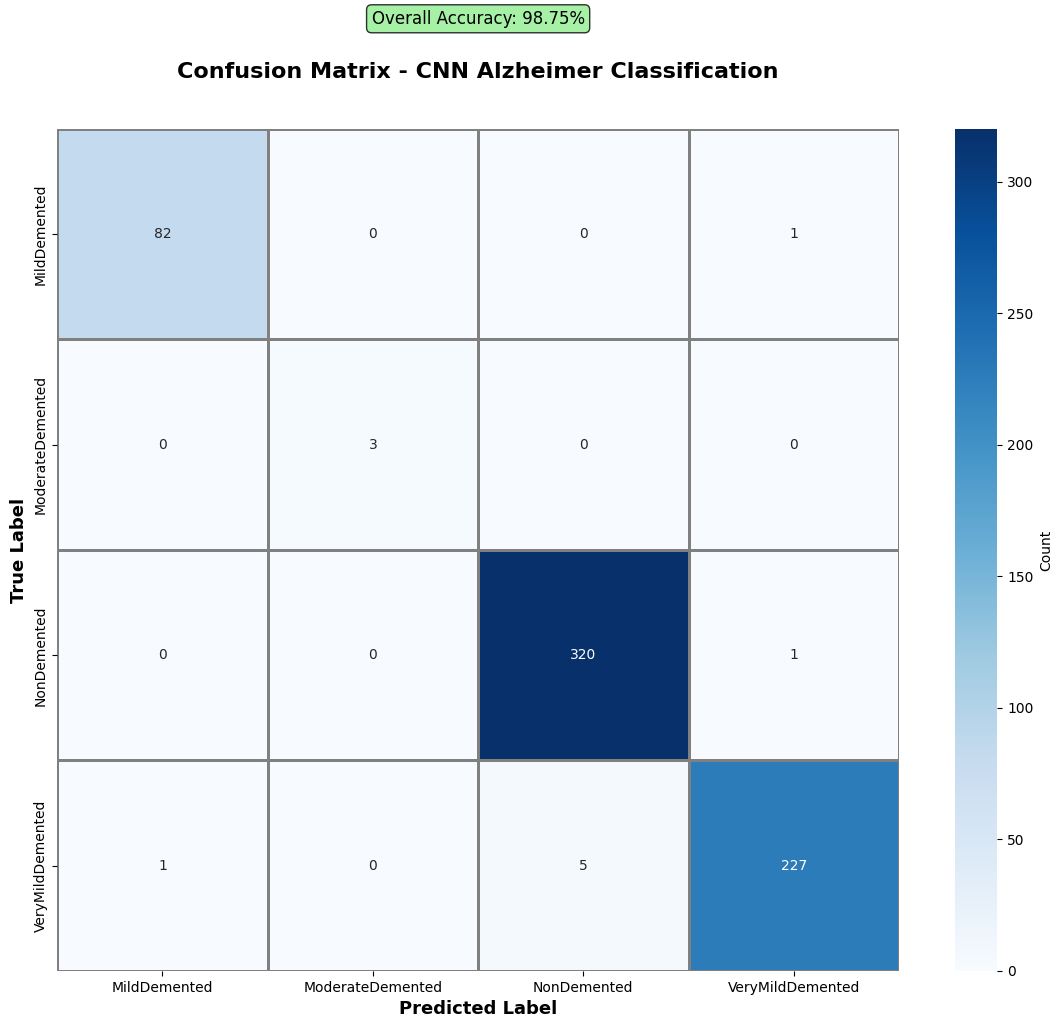


📊 Per-Class Accuracy:
  MildDemented        :  98.80% (82/83)
  ModerateDemented    : 100.00% (3/3)
  NonDemented         :  99.69% (320/321)
  VeryMildDemented    :  97.42% (227/233)


In [ ]:
# CELL 2 - Code
print("Generating confusion matrix...\n")

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Create visualization
plt.figure(figsize=(12, 10))

# Plot heatmap
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=CONFIG['CLASS_NAMES'],
    yticklabels=CONFIG['CLASS_NAMES'],
    cbar_kws={'label': 'Count'},
    square=True,
    linewidths=1,
    linecolor='gray'
)

plt.title('Confusion Matrix - CNN Alzheimer Classification\n', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')

# Add accuracy annotation
plt.text(
    2, -0.5, 
    f'Overall Accuracy: {test_accuracy:.2f}%',
    fontsize=12,
    ha='center',
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
)

plt.tight_layout()

# Save
cm_path = os.path.join(CONFIG['OUTPUT_DIR'], 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f"✅ Confusion matrix saved to: {cm_path}")
plt.show()

# Calculate per-class accuracy
print("\n📊 Per-Class Accuracy:")
for i, class_name in enumerate(CONFIG['CLASS_NAMES']):
    class_correct = cm[i, i]
    class_total = cm[i, :].sum()
    class_acc = 100. * class_correct / class_total if class_total > 0 else 0
    print(f"  {class_name:20s}: {class_acc:6.2f}% ({class_correct}/{class_total})")

Generating ROC curves...

✅ ROC curves saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch\roc_curves.png


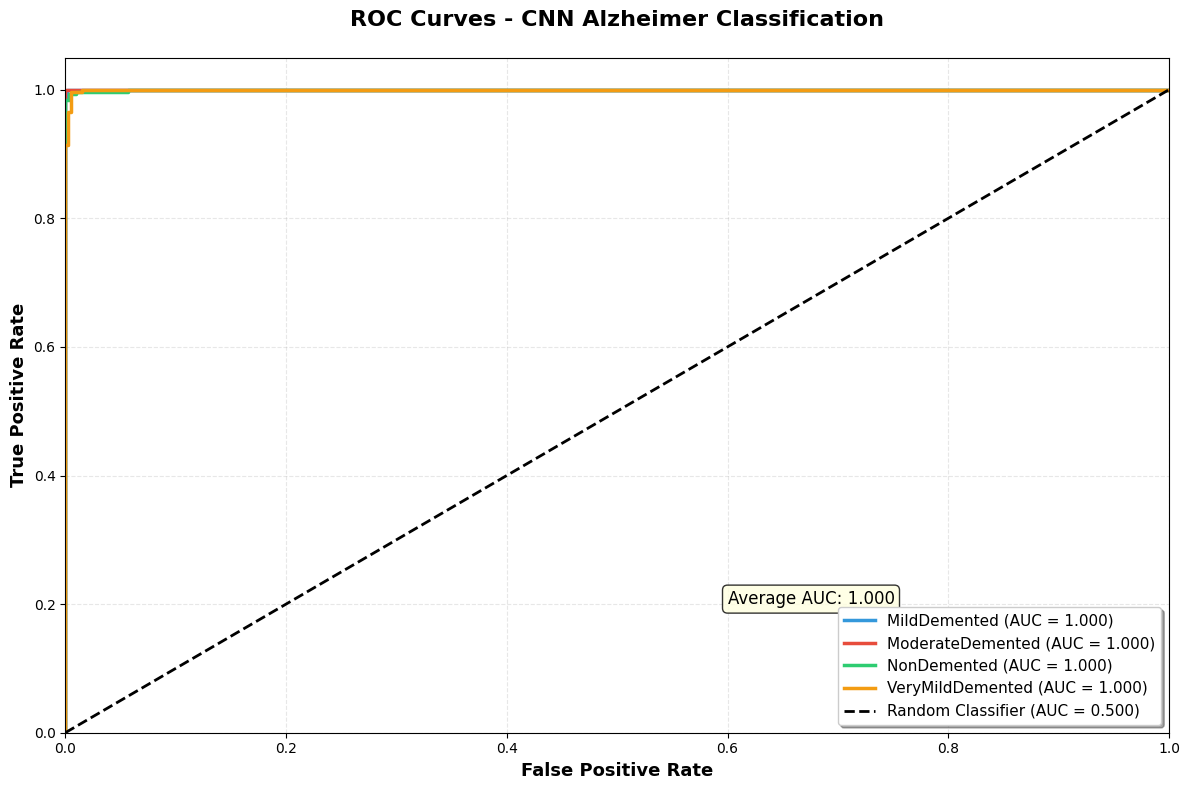


📊 AUC Scores per Class:
  MildDemented        : 1.0000
  ModerateDemented    : 1.0000
  NonDemented         : 0.9998
  VeryMildDemented    : 0.9997

  Average             : 0.9999


In [13]:
# CELL 2 - Code
print("Generating ROC curves...\n")

# Binarize labels for multiclass ROC
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(all_labels, classes=range(CONFIG['NUM_CLASSES']))

# Create figure
plt.figure(figsize=(12, 8))

# Plot ROC curve for each class
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
auc_scores = []

for i, (class_name, color) in enumerate(zip(CONFIG['CLASS_NAMES'], colors)):
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    
    # Plot
    plt.plot(
        fpr, tpr, 
        color=color, 
        lw=2.5,
        label=f'{class_name} (AUC = {roc_auc:.3f})'
    )

# Plot random classifier line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - CNN Alzheimer Classification\n', 
          fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')

# Add text box with average AUC
avg_auc = np.mean(auc_scores)
plt.text(
    0.6, 0.2,
    f'Average AUC: {avg_auc:.3f}',
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()

# Save
roc_path = os.path.join(CONFIG['OUTPUT_DIR'], 'roc_curves.png')
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f"✅ ROC curves saved to: {roc_path}")
plt.show()

# Print AUC scores
print("\n📊 AUC Scores per Class:")
for class_name, auc_score in zip(CONFIG['CLASS_NAMES'], auc_scores):
    print(f"  {class_name:20s}: {auc_score:.4f}")
print(f"\n  {'Average':20s}: {avg_auc:.4f}")

Generating training history plots...

✅ Training history saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\notebooks\outputs\Q1\Q1a_CNN_Alzheimer_PyTorch\training_history.png


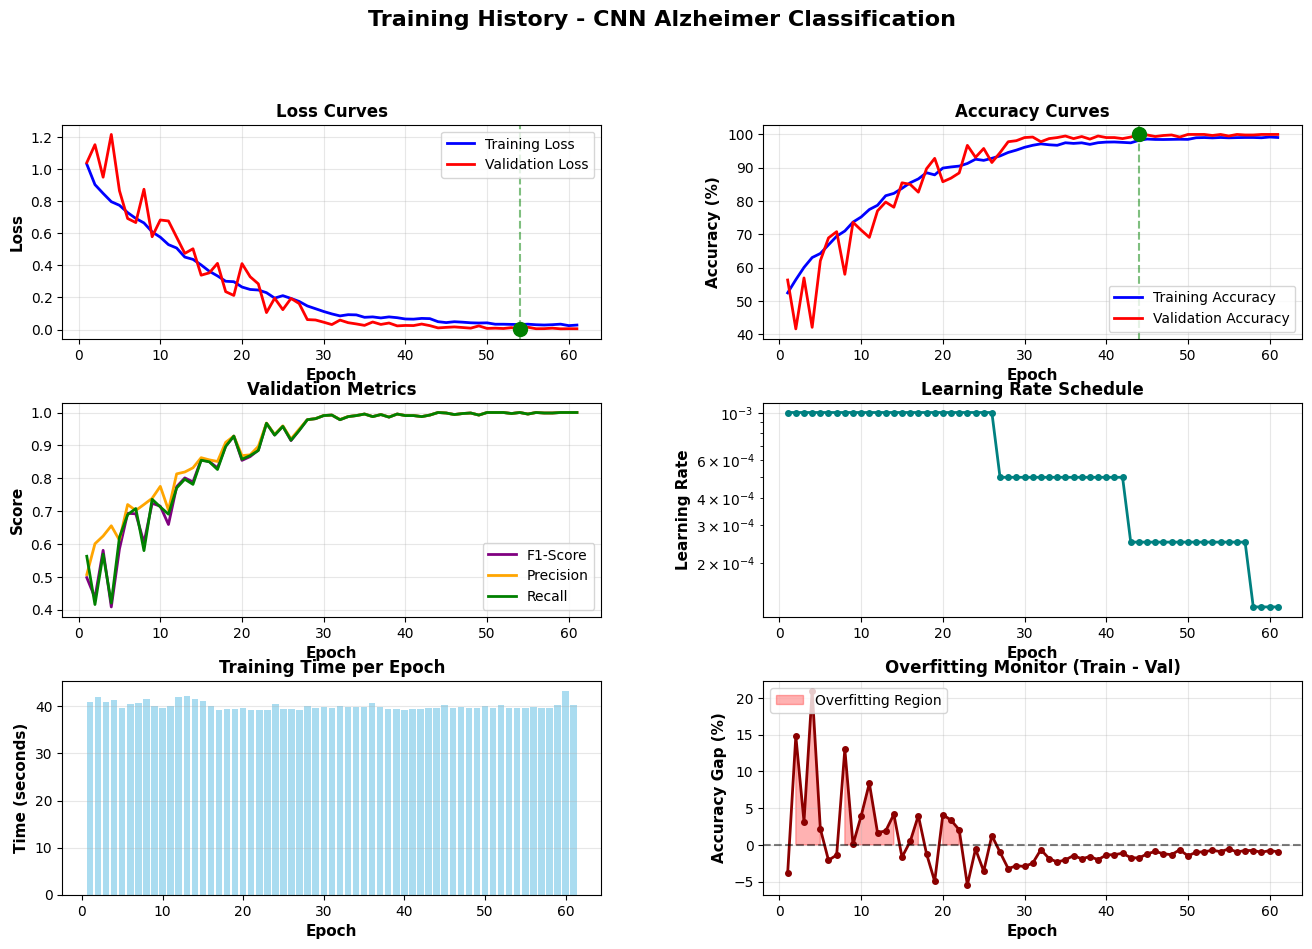


📊 Training Summary:
  Total epochs: 61
  Best validation accuracy: 100.00% (epoch 44)
  Best validation loss: 0.0039 (epoch 54)
  Final learning rate: 0.000125
  Average epoch time: 40.09s
  Total training time: 40.76 minutes


In [14]:
# CELL 2 - Code
print("Generating training history plots...\n")

# Load training history
history = metric_tracker.history

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history['epoch'], history['train_loss'], 'b-', linewidth=2, label='Training Loss')
ax1.plot(history['epoch'], history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax1.set_title('Loss Curves', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# Mark best epoch
best_epoch_idx = history['val_loss'].index(min(history['val_loss']))
ax1.axvline(x=history['epoch'][best_epoch_idx], color='g', linestyle='--', alpha=0.5, label='Best Model')
ax1.plot(history['epoch'][best_epoch_idx], history['val_loss'][best_epoch_idx], 
         'go', markersize=10, label='Best Validation Loss')

# 2. Accuracy curves
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history['epoch'], history['train_acc'], 'b-', linewidth=2, label='Training Accuracy')
ax2.plot(history['epoch'], history['val_acc'], 'r-', linewidth=2, label='Validation Accuracy')
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax2.set_title('Accuracy Curves', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

# Mark best epoch
best_acc_idx = history['val_acc'].index(max(history['val_acc']))
ax2.axvline(x=history['epoch'][best_acc_idx], color='g', linestyle='--', alpha=0.5)
ax2.plot(history['epoch'][best_acc_idx], history['val_acc'][best_acc_idx], 
         'go', markersize=10, label='Best Validation Accuracy')

# 3. F1, Precision, Recall
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(history['epoch'], history['val_f1'], 'purple', linewidth=2, label='F1-Score')
ax3.plot(history['epoch'], history['val_precision'], 'orange', linewidth=2, label='Precision')
ax3.plot(history['epoch'], history['val_recall'], 'green', linewidth=2, label='Recall')
ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
ax3.set_title('Validation Metrics', fontsize=12, fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(alpha=0.3)

# 4. Learning rate schedule
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(history['epoch'], history['learning_rate'], 'teal', linewidth=2, marker='o', markersize=4)
ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax4.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
ax4.set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
ax4.set_yscale('log')
ax4.grid(alpha=0.3)

# 5. Epoch time
ax5 = fig.add_subplot(gs[2, 0])
ax5.bar(history['epoch'], history['epoch_time'], color='skyblue', alpha=0.7)
ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax5.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
ax5.set_title('Training Time per Epoch', fontsize=12, fontweight='bold')
ax5.grid(alpha=0.3, axis='y')

# 6. Train vs Val gap
ax6 = fig.add_subplot(gs[2, 1])
gap = [train - val for train, val in zip(history['train_acc'], history['val_acc'])]
ax6.plot(history['epoch'], gap, 'darkred', linewidth=2, marker='o', markersize=4)
ax6.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax6.fill_between(history['epoch'], 0, gap, where=[g > 0 for g in gap], 
                 color='red', alpha=0.3, label='Overfitting Region')
ax6.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax6.set_ylabel('Accuracy Gap (%)', fontsize=11, fontweight='bold')
ax6.set_title('Overfitting Monitor (Train - Val)', fontsize=12, fontweight='bold')
ax6.legend(loc='upper left')
ax6.grid(alpha=0.3)

# Main title
fig.suptitle('Training History - CNN Alzheimer Classification', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()

# Save
history_path = os.path.join(CONFIG['OUTPUT_DIR'], 'training_history.png')
plt.savefig(history_path, dpi=300, bbox_inches='tight')
print(f"✅ Training history saved to: {history_path}")
plt.show()

# Print summary statistics
print("\n📊 Training Summary:")
print(f"  Total epochs: {len(history['epoch'])}")
print(f"  Best validation accuracy: {max(history['val_acc']):.2f}% (epoch {best_acc_idx + 1})")
print(f"  Best validation loss: {min(history['val_loss']):.4f} (epoch {best_epoch_idx + 1})")
print(f"  Final learning rate: {history['learning_rate'][-1]:.6f}")
print(f"  Average epoch time: {np.mean(history['epoch_time']):.2f}s")
print(f"  Total training time: {sum(history['epoch_time'])/60:.2f} minutes")